Graph loaded successfully.


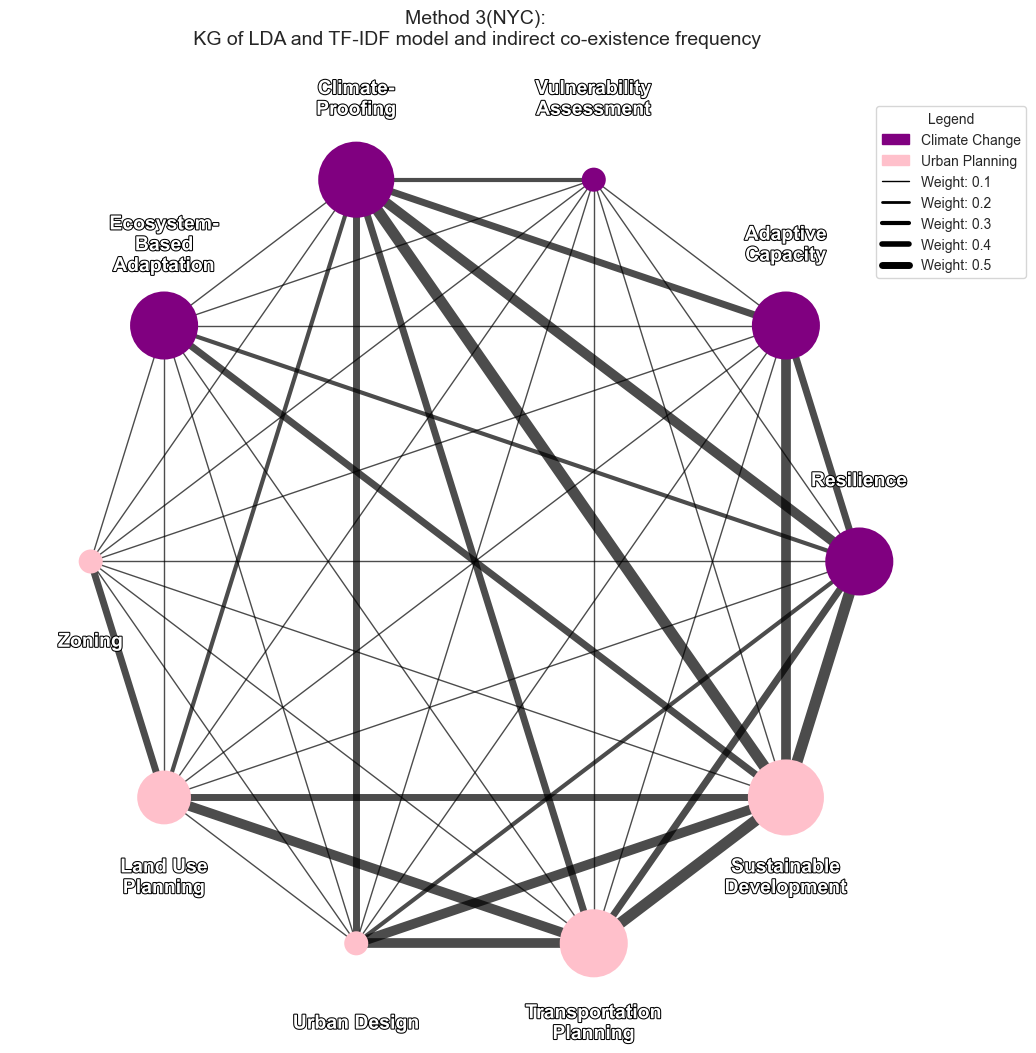

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pickle
import textwrap  # 用于自动换行
import matplotlib.lines as mlines  # 用于自定义线条图例
# 添加图例
import matplotlib.patches as mpatches


# 加载图形
kmeans_path = r'D:\KG\weighted_graph_chatgpt_NYC_plan.pkl'

with open(kmeans_path, 'rb') as f:
    graph = pickle.load(f)

print("Graph loaded successfully.")

# 圆形布局
pos = nx.circular_layout(graph)  # 使用圆形布局

# 定义颜色映射：不同的类别对应不同的颜色
category_colors = {
    'climate change': 'purple',
    'urban planning': 'pink'
}

# 获取节点属性
node_sizes = [attributes['weight'] * 300 for _, attributes in graph.nodes(data=True)]
node_colors = [category_colors[attributes['category']] for _, attributes in graph.nodes(data=True)]
edge_weights = [graph.edges[edge].get('weight', 1) for edge in graph.edges]

# 获取节点标签
labels = {node: node for node in graph.nodes}

# 设置文本最大宽度
max_label_length = 14  # 可以根据需要调整字符数

# 绘制节点
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(
    graph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',  # 将描边颜色设置为白色
    linewidths=0,  # 设置节点边缘线宽为10
    alpha=1
)

# 绘制边，统一紫色
edge_widths = [weight for weight in edge_weights]
nx.draw_networkx_edges(
    graph, pos,
    width=edge_widths,
    edge_color="black",
    alpha=0.7
)

# 绘制节点标签（文字白色，黑色描边），并将标签放置在上、下、左、右
for node, (x, y) in pos.items():
    label = labels[node]
    weight = graph.nodes[node].get('weight', 1)  # 获取节点的权重
    label_with_weight = f"{label}    "  # 格式化标签和权重\n\n(V: {weight})

    # 使用 textwrap 处理标签换行
    wrapped_label = textwrap.fill(label_with_weight, width=max_label_length)  # 根据最大字符数换行

    # 根据节点位置确定标签放置位置
    if y >= 0:  # 如果节点位于圆形的上半部分
        y_offset = y + 0.2  # 标签向上偏移
        x_offset = x
    else:  # 如果节点位于圆形的下半部分
        y_offset = y - 0.2  # 标签向下偏移
        x_offset = x

    # 绘制带权重的标签
    text = plt.text(
        x_offset, y_offset, wrapped_label,
        fontsize=14,
        fontweight='bold',  # 设置为粗体
        color='white',
        ha='center',
        va='center',
        zorder=2
    )
    text.set_path_effects([  # 设置文字描边
        path_effects.Stroke(linewidth=1.5, foreground='black'),
        path_effects.Normal()
    ])


# 创建线条粗细的图例
line_widths = [1, 2, 3, 4, 5]  # 示例的边权重对应的线宽
legend_lines = [mlines.Line2D([0], [0], color="black", lw=width) for width in line_widths]
legend_labels = [f'Weight: {width/10}' for width in line_widths]  # 图例标签

# 将颜色图例与线条粗细图例放在一起
color_legend = [mpatches.Patch(color='purple', label='Climate Change'),
                mpatches.Patch(color='pink', label='Urban Planning')]

# 使用plt.legend()并传递labels参数
plt.legend(handles=color_legend + legend_lines, labels=['Climate Change', 'Urban Planning'] + legend_labels, loc='upper right',
           bbox_to_anchor=(1.1, 1), title="Legend", fontsize=10)


# 显示图形
plt.title("Method 3(NYC):"
          "\n KG of LDA and TF-IDF model and indirect co-existence frequency", fontsize=14, pad=40)
plt.axis('off')
plt.show()


In [16]:
node_sizes

[1600.0, 1600.0, 200.0, 2000.0, 1600.0, 200.0, 1000.0, 200.0, 1600.0, 2000.0]

Graph loaded successfully.
[5.0, 7.0, 3.0, 3.0, 5.0, 8.0, 5.0, 7.0, 3.0, 3.0, 5.0, 5.0, 8.0, 5.0, 5.0, 7.0, 5.0, 7.0, 7.0, 8.0]
range(3, 9)


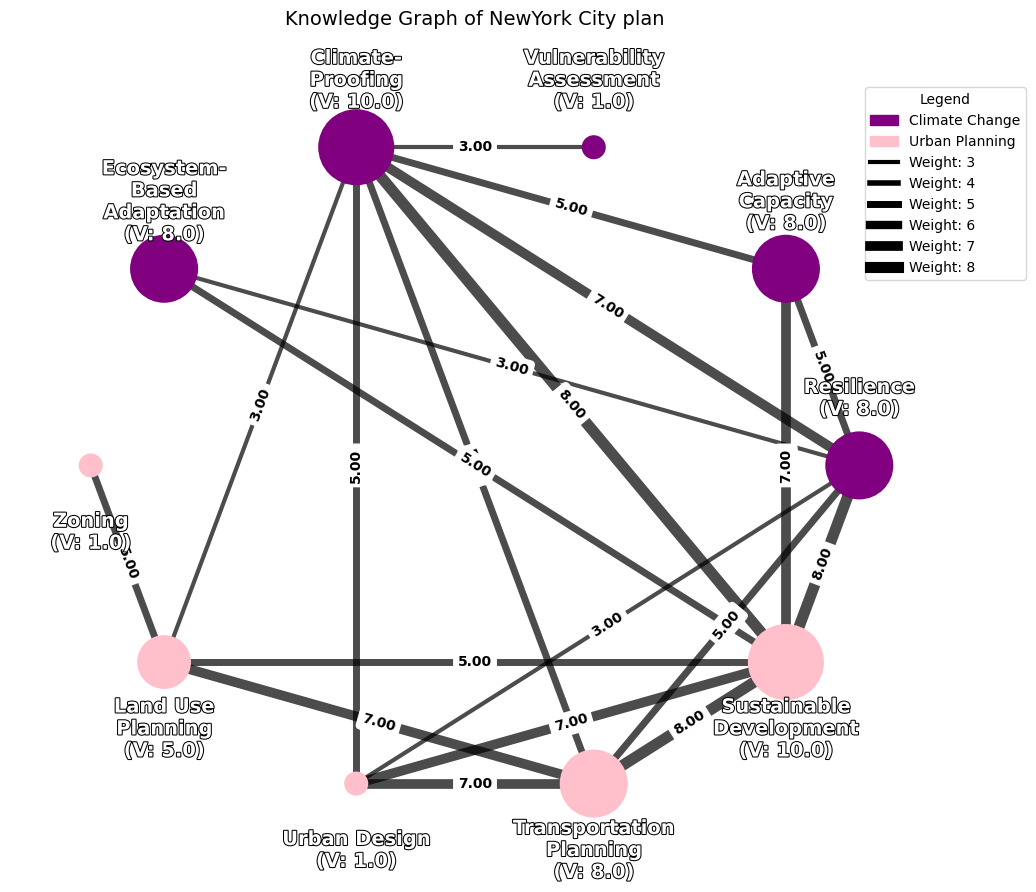

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pickle
import textwrap  # 用于自动换行
import matplotlib.lines as mlines  # 用于自定义线条图例
import matplotlib.patches as mpatches

# 加载图形
kmeans_path = r'D:\KG\weighted_graph_chatgpt_NYC_plan.pkl'

with open(kmeans_path, 'rb') as f:
    graph = pickle.load(f)

print("Graph loaded successfully.")

# 圆形布局
pos = nx.circular_layout(graph)  # 使用圆形布局

# 定义颜色映射：不同的类别对应不同的颜色
category_colors = {
    'climate change': 'purple',
    'urban planning': 'pink'
}

# 获取节点属性
node_sizes = [attributes['weight'] * 300 for _, attributes in graph.nodes(data=True)]
node_colors = [category_colors[attributes['category']] for _, attributes in graph.nodes(data=True)]

# 过滤掉权重为1的边
edges_to_remove = [(u, v) for u, v in graph.edges if graph[u][v].get('weight', 1) == 1]
graph.remove_edges_from(edges_to_remove)

# 获取节点标签
labels = {node: node for node in graph.nodes}

# 设置文本最大宽度
max_label_length = 14  # 可以根据需要调整字符数

# 绘制节点
plt.figure(figsize=(12, 10))

nx.draw_networkx_nodes(
    graph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',  # 将描边颜色设置为白色
    linewidths=0,  # 设置节点边缘线宽为10
    alpha=1
)

# 绘制边，使用原始边权重作为线宽
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]
nx.draw_networkx_edges(
    graph, pos,
    width=edge_weights,
    edge_color="black",
    alpha=0.7
)

# 获取原始的边权重
edge_weights = [graph.edges[edge].get('weight', 1) for edge in graph.edges]
print(edge_weights)

# 在每条边的中间添加权重标签
edge_labels = {(u, v): f'{graph[u][v].get("weight", 1):.2f}' for u, v in graph.edges}
nx.draw_networkx_edge_labels(
    graph, pos,
    edge_labels=edge_labels,
    font_size=10,
    #font_color='red',  # 标签颜色
    font_weight='bold',  # 标签字体加粗
    verticalalignment='center',  # 标签垂直对齐方式
    horizontalalignment='center',  # 标签水平对齐方式
)

# 绘制节点标签（文字白色，黑色描边），并将标签放置在上、下、左、右
for node, (x, y) in pos.items():
    label = labels[node]
    weight = graph.nodes[node].get('weight', 1)  # 获取节点的权重
    label_with_weight = f"{label}    \n\n(V: {weight})"  # 格式化标签和权重

    # 使用 textwrap 处理标签换行
    wrapped_label = textwrap.fill(label_with_weight, width=max_label_length)  # 根据最大字符数换行

    # 根据节点位置确定标签放置位置
    if y >= 0:  # 如果节点位于圆形的上半部分
        y_offset = y + 0.2  # 标签向上偏移
        x_offset = x
    else:  # 如果节点位于圆形的下半部分
        y_offset = y - 0.2  # 标签向下偏移
        x_offset = x

    # 绘制带权重的标签
    text = plt.text(
        x_offset, y_offset, wrapped_label,
        fontsize=14,
        fontweight='bold',  # 设置为粗体
        color='white',
        ha='center',
        va='center',
        zorder=2
    )
    text.set_path_effects([  # 设置文字描边
        path_effects.Stroke(linewidth=1.5, foreground='black'),
        path_effects.Normal()
    ])

# 创建线条粗细的图例
# 获取所有边的权重值
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]

# 获取最小、最大边权重
min_weight = min(edge_weights)
max_weight = max(edge_weights)

# 创建一组权重值，用于生成图例（根据实际情况，可以选择几个代表性的权重值）
# 这里我们选择最小、中间和最大的权重值
legend_weights = range(int(min_weight),int(max_weight+1),1)
print(legend_weights)

legend_lines = [mlines.Line2D([0], [0], color="black", lw=width) for width in legend_weights]
legend_labels = [f'Weight: {width}' for width in legend_weights]  # 图例标签

# 将颜色图例与线条粗细图例放在一起
color_legend = [mpatches.Patch(color='purple', label='Climate Change'),
                mpatches.Patch(color='pink', label='Urban Planning')]

# 使用 plt.legend 并传递动态生成的线条粗细图例
plt.legend(handles=color_legend + legend_lines,
           labels=['Climate Change', 'Urban Planning'] + legend_labels,
           loc='upper right',
           bbox_to_anchor=(1.1, 1),
           title="Legend",
           fontsize=10)

# 显示图形
plt.title("Knowledge Graph of NewYork City plan", fontsize=14, pad=40)
plt.axis('off')
plt.show()


Graph loaded successfully.
[5.0, 7.0, 3.0, 3.0, 5.0, 8.0, 5.0, 7.0, 3.0, 3.0, 5.0, 5.0, 8.0, 5.0, 5.0, 7.0, 5.0, 7.0, 7.0, 8.0]
range(3, 9)
[5.6, 9.2, 12.8, 16.4, 20.0]


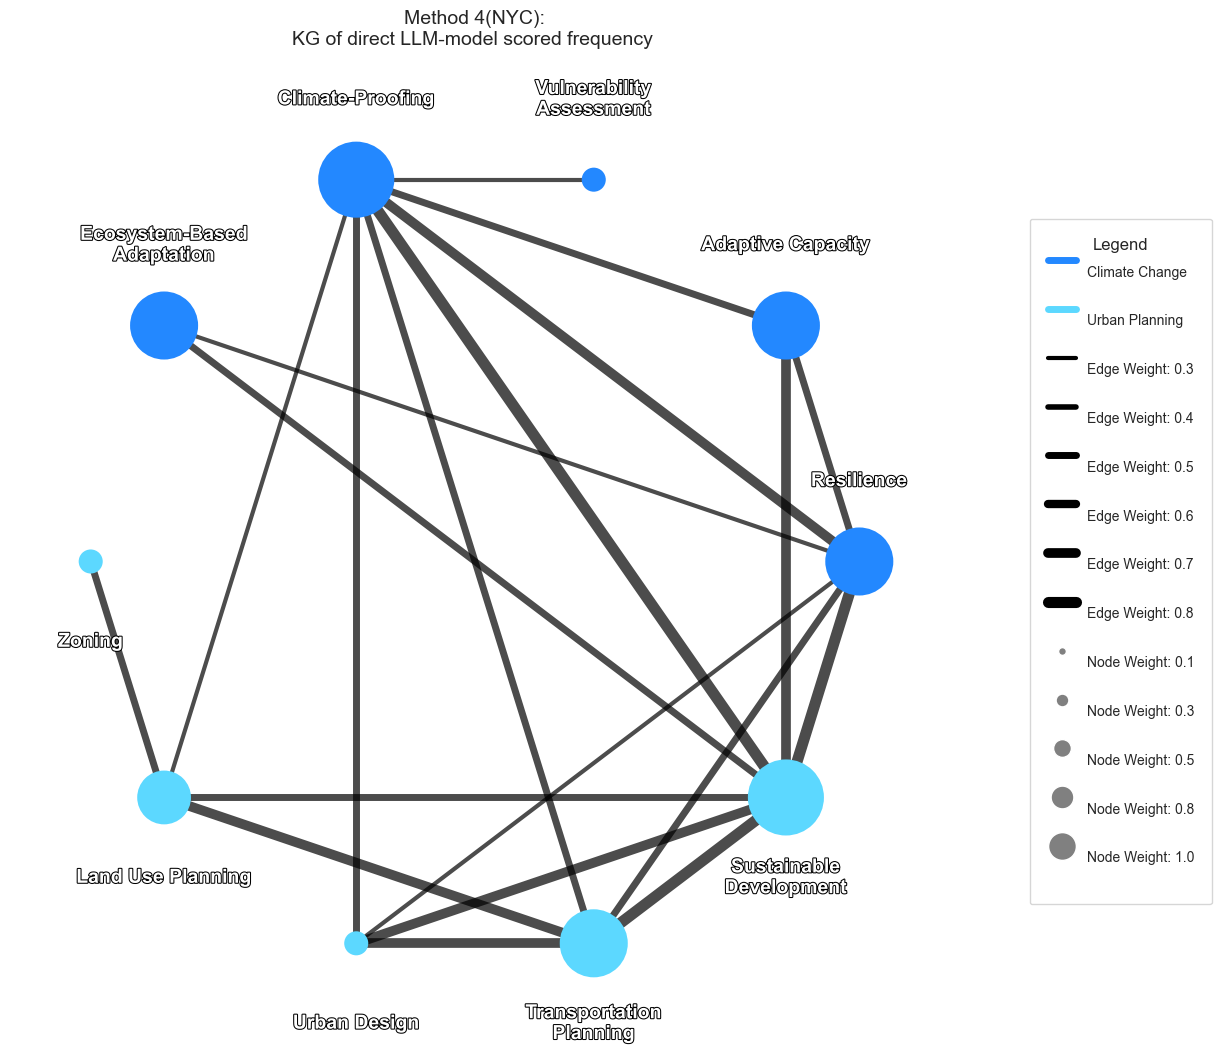

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pickle
import textwrap  # 用于自动换行
import matplotlib.lines as mlines  # 用于自定义线条图例
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import textwrap

# 加载图形
kmeans_path = r'D:\KG\weighted_graph_chatgpt_NYC_plan.pkl'

with open(kmeans_path, 'rb') as f:
    graph = pickle.load(f)

print("Graph loaded successfully.")

# 圆形布局
pos = nx.circular_layout(graph)  # 使用圆形布局

# 定义颜色映射：不同的类别对应不同的颜色
category_colors = {
    'climate change': '#2388FF',
    'urban planning': '#5CD8FF'
}

# 获取节点属性
node_sizes = [attributes['weight'] * 300 for _, attributes in graph.nodes(data=True)]
node_colors = [category_colors[attributes['category']] for _, attributes in graph.nodes(data=True)]

# 过滤掉权重为1的边
edges_to_remove = [(u, v) for u, v in graph.edges if graph[u][v].get('weight', 1) == 1]
graph.remove_edges_from(edges_to_remove)

# 获取节点标签
labels = {node: node for node in graph.nodes}

# 设置文本最大宽度
max_label_length = 14  # 可以根据需要调整字符数

# 绘制节点
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(
    graph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',  # 将描边颜色设置为白色
    linewidths=0,  # 设置节点边缘线宽为10
    alpha=1
)

# 绘制边，使用原始边权重作为线宽
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]
nx.draw_networkx_edges(
    graph, pos,
    width=edge_weights,
    edge_color="black",
    alpha=0.7
)

# 获取原始的边权重
edge_weights = [graph.edges[edge].get('weight', 1) for edge in graph.edges]
print(edge_weights)

# 在每条边的中间添加权重标签
edge_labels = {(u, v): f'{graph[u][v].get("weight", 1):.2f}' for u, v in graph.edges}



def draw_node_labels(graph, pos, labels, max_label_length=20):
    """
    绘制节点标签（带有描边）并根据节点位置将标签放置在不同位置（上、下、左、右）。

    :param graph: 网络图对象 (networkx.Graph)
    :param pos: 节点位置字典，形如 {node: (x, y)}
    :param labels: 标签字典，形如 {node: label}
    :param max_label_length: 每行标签的最大字符数（用于换行处理）
    """
    for node, (x, y) in pos.items():
        label = labels[node]
        weight = graph.nodes[node].get('weight', 1)  # 获取节点的权重
        label_with_weight = f"{label}    "  # 可以在这里添加更多信息，如权重等

        # 使用 textwrap 处理标签换行
        wrapped_label = textwrap.fill(label_with_weight, width=max_label_length)  # 根据最大字符数换行

        # 根据节点位置确定标签放置位置
        if y >= 0:  # 如果节点位于圆形的上半部分
            y_offset = y + 0.2  # 标签向上偏移
            x_offset = x
        else:  # 如果节点位于圆形的下半部分
            y_offset = y - 0.2  # 标签向下偏移
            x_offset = x

        # 绘制带权重的标签
        text = plt.text(
            x_offset, y_offset, wrapped_label,
            fontsize=14,
            fontweight='bold',  # 设置为粗体
            color='white',
            ha='center',
            va='center',
            zorder=2
        )
        text.set_path_effects([  # 设置文字描边
            path_effects.Stroke(linewidth=1.5, foreground='black'),
            path_effects.Normal()
        ])

# 假设你已经有了 graph, pos 和 labels 变量
draw_node_labels(graph, pos, labels)



# 01创建线条粗细的图例
# 获取所有边的权重值
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]

# 获取最小、最大边权重
min_weight = min(edge_weights)
max_weight = max(edge_weights)

# 创建一组权重值，用于生成图例（根据实际情况，可以选择几个代表性的权重值）
# 这里我们选择最小、中间和最大的权重值
legend_weights = range(int(min_weight),int(max_weight+1),1)
print(legend_weights)

edges_lines = [mlines.Line2D([0], [0], color="black", lw=width) for width in legend_weights]
edges_labels = [f'Edge Weight: {width/10}' for width in legend_weights]  # 图例标签

# 01 定义颜色图例
# 02 定义与颜色相关的线条图例
color_list = ['#2388FF', '#5CD8FF']  # 颜色列表
color_labels = [mlines.Line2D([0], [0], color=color, lw=5) for color in color_list]  # 为每个颜色创建一个对应的图例项
# 03 创建一个单独的标签（‘Climate Change’, ‘Urban Planning’）
category_labels = ['Climate Change', 'Urban Planning']

# 01 获取图中节点的大小范围
min_size = min(node_sizes)/30/5
max_size = max(node_sizes)/30/5

# 02 定义图例中节点的大小范围，确保与图中节点大小的比例一致
# 例如，将图例大小映射到图中实际的最小和最大值之间
legend_node_sizes = [min_size + (max_size - min_size) * i / 5 for i in range(1, 6)]  # 创建4个不同的大小值用于图例
print(legend_node_sizes)
# 03 创建图例中的节点圆圈图例，确保图例中的大小与实际图中节点大小一致
nodes_circles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=size) for size in legend_node_sizes]
name =[1,3,5,8,10]
# 04 更新图例标签
nodes_labels = [f'Node Weight: {weight/10}' for weight in name]  # 根据实际节点大小计算并显示标签


#将颜色图例与线条粗细图例放在一起
# 使用 plt.legend 并传递动态生成的线条粗细图例
plt.legend(title="Legend",
           title_fontsize=12,
           handles=color_labels + edges_lines + nodes_circles,
           labels=category_labels + edges_labels + nodes_labels,
           loc='right',
           bbox_to_anchor=(1.3, 0.5),
           fontsize=10,
           labelspacing=-0.5,
           handlelength=2,
           handleheight=5.8,
           borderaxespad=0.5,  # 控制图例框和轴之间的间距
           borderpad=1.3,  # 设置图例框内边距（框和内容之间的间距）
           frameon=True,
           fancybox=True,
           mode='mode'
           )

# 显示图形
plt.title("Method 4(NYC):"
          "\nKG of direct LLM-model scored frequency ", fontsize=14, pad=40)
plt.axis('off')
plt.show()


In [23]:


data = {'Resilience': 6, 'Adaptive Capacity': 3, 'Vulnerability Assessment': 1, 'Climate-Proofing': 7, 'Ecosystem-Based Adaptation': 2, 'Zoning': 1, 'Land Use Planning': 4, 'Urban Design': 4, 'Transportation Planning': 5, 'Sustainable Development': 7}
data = {key.lower(): value for key, value in data.items()}

print(data)

{'resilience': 6, 'adaptive capacity': 3, 'vulnerability assessment': 1, 'climate-proofing': 7, 'ecosystem-based adaptation': 2, 'zoning': 1, 'land use planning': 4, 'urban design': 4, 'transportation planning': 5, 'sustainable development': 7}


In [24]:
# Ensure values are rounded and formatted to 4 decimal places
V1_rounded = {key: format(value/10, '.1f') for key, value in data.items()}

print(V1_rounded)

{'resilience': '0.6', 'adaptive capacity': '0.3', 'vulnerability assessment': '0.1', 'climate-proofing': '0.7', 'ecosystem-based adaptation': '0.2', 'zoning': '0.1', 'land use planning': '0.4', 'urban design': '0.4', 'transportation planning': '0.5', 'sustainable development': '0.7'}


Graph loaded successfully.
[5.0, 7.0, 3.0, 3.0, 5.0, 8.0, 5.0, 7.0, 3.0, 3.0, 5.0, 5.0, 8.0, 5.0, 5.0, 7.0, 5.0, 7.0, 7.0, 8.0]
range(3, 9)
[3.7333333333333334, 6.133333333333333, 8.533333333333333, 10.933333333333334, 13.333333333333334]


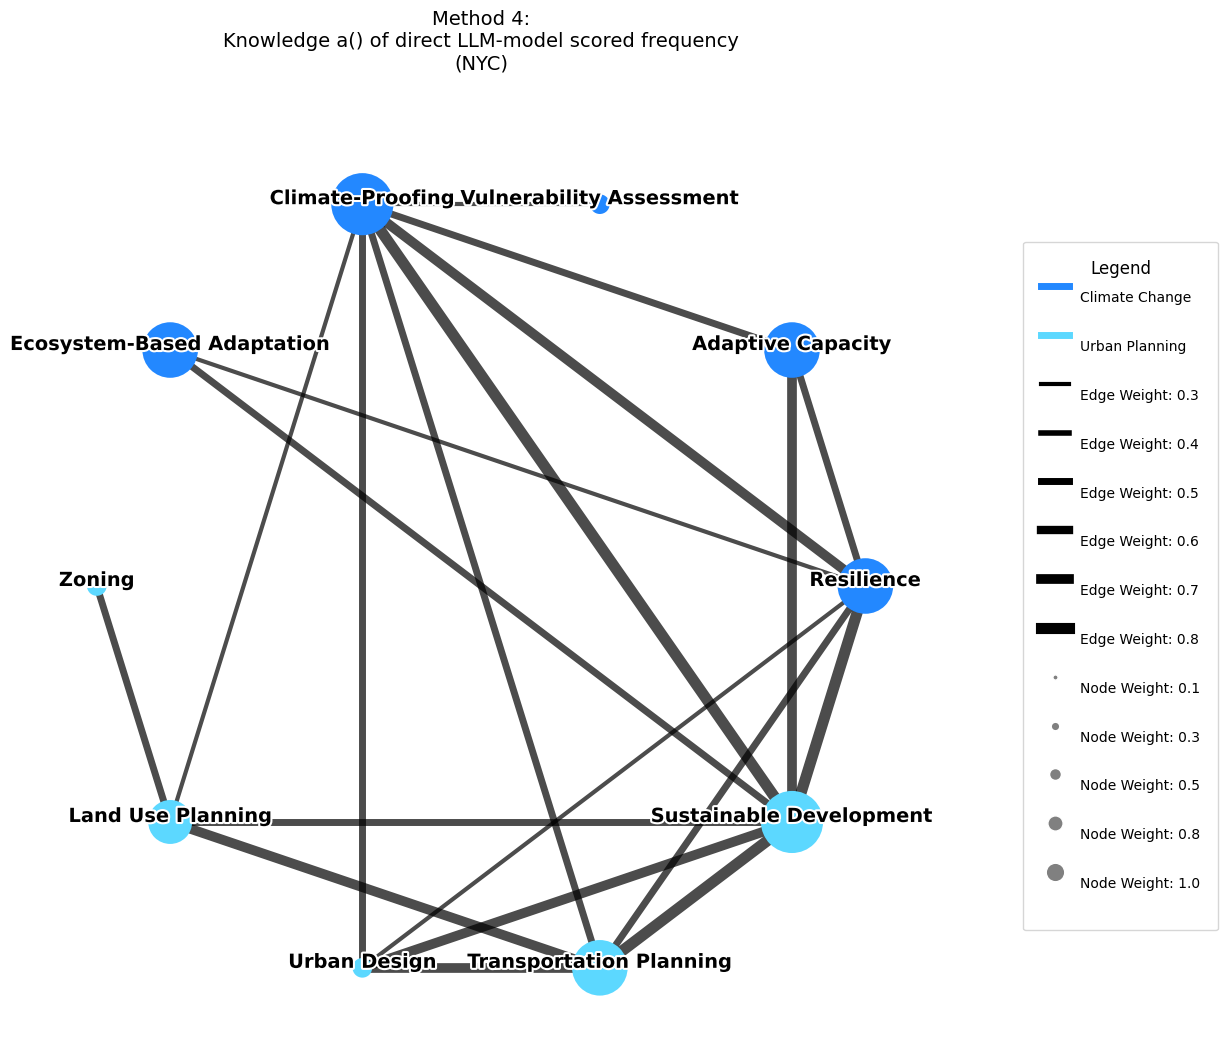

In [48]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pickle
import textwrap  # 用于自动换行
import matplotlib.lines as mlines  # 用于自定义线条图例
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import textwrap

# 加载图形
kmeans_path = r'D:\KG\weighted_graph_chatgpt_NYC_plan.pkl'

with open(kmeans_path, 'rb') as f:
    graph = pickle.load(f)

print("Graph loaded successfully.")

# 圆形布局
pos = nx.circular_layout(graph)  # 使用圆形布局

# 定义颜色映射：不同的类别对应不同的颜色
category_colors = {
    'climate change': '#2388FF',
    'urban planning': '#5CD8FF'
}
j=200
# 获取节点属性
node_sizes = [attributes['weight'] * j for _, attributes in graph.nodes(data=True)]
node_colors = [category_colors[attributes['category']] for _, attributes in graph.nodes(data=True)]

# 过滤掉权重为1的边
edges_to_remove = [(u, v) for u, v in graph.edges if graph[u][v].get('weight', 1) == 1]
graph.remove_edges_from(edges_to_remove)

# 获取节点标签
labels = {node: node for node in graph.nodes}

# 绘制节点
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(
    graph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',  # 将描边颜色设置为白色
    linewidths=0,  # 设置节点边缘线宽为10
    alpha=1
)

# 绘制边，使用原始边权重作为线宽
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]
nx.draw_networkx_edges(
    graph, pos,
    width=edge_weights,
    edge_color="black",
    alpha=0.7
)
# 取消 nx.draw_networkx_labels，直接用自定义文本绘制
# nx.draw_networkx_labels(graph, pos, labels={node: node.upper() for node in fixed_node_list}, font_size=14)

# 使用自定义标签绘制
for node, (x, y) in pos.items():
    # 获取节点名称并转为大写
    label = node.title()

    # 自动按空格换行，限制每行最大字符数（例如：15个字符）
    wrapped_label = "\n".join(textwrap.wrap(label, width=15))

    # 绘制节点标签并添加白色描边
    text = plt.text(
        x, y, label, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 白色描边
        path_effects.Normal()  # 恢复正常文字颜色
    ])

# 获取原始的边权重
edge_weights = [graph.edges[edge].get('weight', 1) for edge in graph.edges]
print(edge_weights)

# 在每条边的中间添加权重标签
edge_labels = {(u, v): f'{graph[u][v].get("weight", 1):.2f}' for u, v in graph.edges}

# 01创建线条粗细的图例
# 获取所有边的权重值
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]

# 获取最小、最大边权重
min_weight = min(edge_weights)
max_weight = max(edge_weights)

# 创建一组权重值，用于生成图例（根据实际情况，可以选择几个代表性的权重值）
# 这里我们选择最小、中间和最大的权重值
legend_weights = range(int(min_weight),int(max_weight+1),1)
print(legend_weights)
k=10
edges_lines = [mlines.Line2D([0], [0], color="black", lw=width) for width in legend_weights]
edges_labels = [f'Edge Weight: {width/k}' for width in legend_weights]  # 图例标签

# 01 定义颜色图例
# 02 定义与颜色相关的线条图例
color_list = ['#2388FF', '#5CD8FF']  # 颜色列表
color_labels = [mlines.Line2D([0], [0], color=color, lw=5) for color in color_list]  # 为每个颜色创建一个对应的图例项
# 03 创建一个单独的标签（‘Climate Change’, ‘Urban Planning’）
category_labels = ['Climate Change', 'Urban Planning']

# 01 获取图中节点的大小范围
min_size = min(node_sizes)/30/5
max_size = max(node_sizes)/30/5

# 02 定义图例中节点的大小范围，确保与图中节点大小的比例一致
# 例如，将图例大小映射到图中实际的最小和最大值之间
legend_node_sizes = [min_size + (max_size - min_size) * i / 5 for i in range(1, 6)]  # 创建4个不同的大小值用于图例
print(legend_node_sizes)
# 03 创建图例中的节点圆圈图例，确保图例中的大小与实际图中节点大小一致
nodes_circles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=size) for size in legend_node_sizes]
name =[1,3,5,8,10]
# 04 更新图例标签
nodes_labels = [f'Node Weight: {weight/k}' for weight in name]  # 根据实际节点大小计算并显示标签


#将颜色图例与线条粗细图例放在一起
# 使用 plt.legend 并传递动态生成的线条粗细图例
plt.legend(title="Legend",
           title_fontsize=12,
           handles=color_labels + edges_lines + nodes_circles,
           labels=category_labels + edges_labels + nodes_labels,
           loc='right',
           bbox_to_anchor=(1.3, 0.5),
           fontsize=10,
           labelspacing=-0.5,
           handleheight=5.8,
           borderpad=1.3,  # 设置图例框内边距（框和内容之间的间距）
           fancybox=True,
           mode='mode'
           )

# 显示图形
plt.title("Method 4:\nKnowledge a() of direct LLM-model scored frequency\n(NYC)", fontsize=14, pad=40)
plt.axis('off')
plt.show()


Graph loaded successfully.
[5.0, 7.0, 3.0, 3.0, 5.0, 8.0, 5.0, 7.0, 3.0, 3.0, 5.0, 5.0, 8.0, 5.0, 5.0, 7.0, 5.0, 7.0, 7.0, 8.0]
[3.   4.25 5.5  6.75 8.  ]


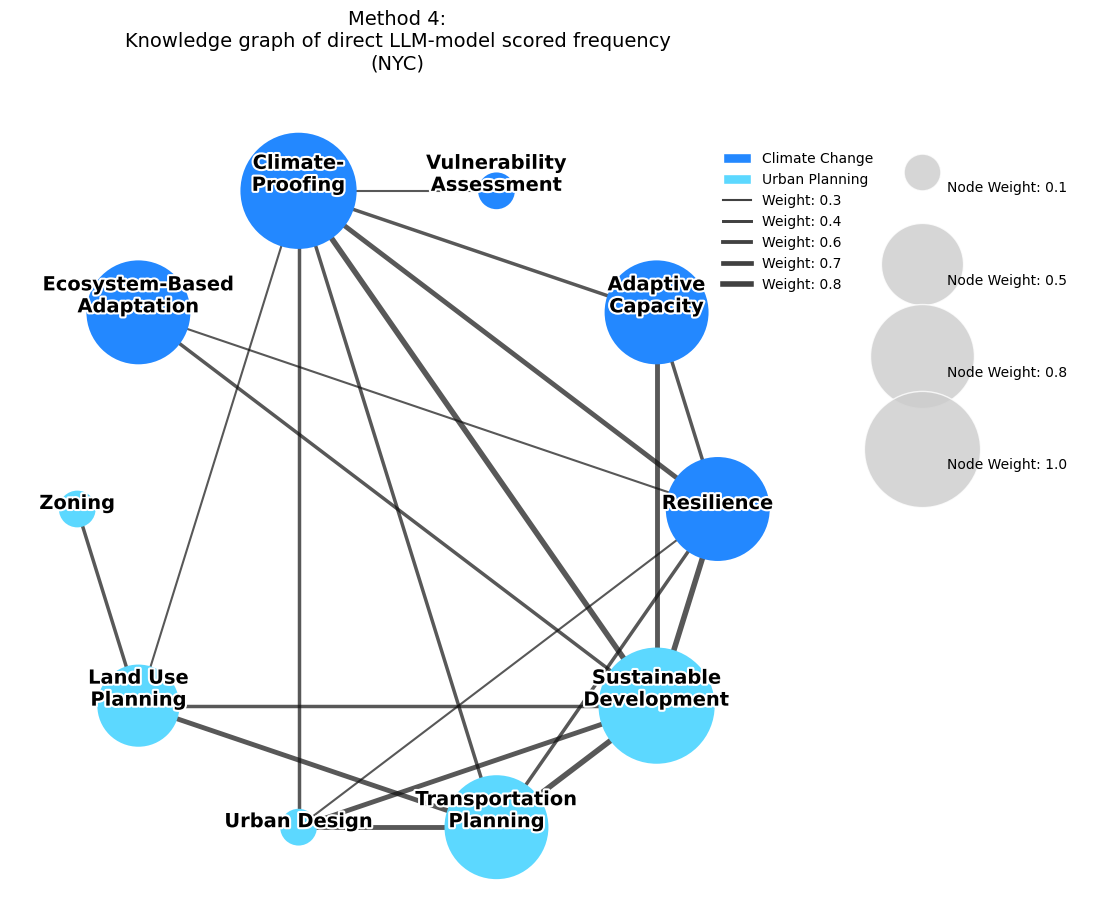

In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pickle
import textwrap  # 用于自动换行
import matplotlib.lines as mlines  # 用于自定义线条图例
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import textwrap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
# 加载图形
kmeans_path = r'D:\KG\weighted_graph_chatgpt_NYC_plan.pkl'

with open(kmeans_path, 'rb') as f:
    graph = pickle.load(f)

print("Graph loaded successfully.")

# 圆形布局
pos = nx.circular_layout(graph)  # 使用圆形布局

# 定义颜色映射：不同的类别对应不同的颜色
category_colors = {
    'climate change': '#2388FF',
    'urban planning': '#5CD8FF'
}
j=700
m=2
k=20
# 获取节点属性
node_sizes = [attributes['weight'] * j for _, attributes in graph.nodes(data=True)]
node_colors = [category_colors[attributes['category']] for _, attributes in graph.nodes(data=True)]

# 过滤掉权重为1的边
edges_to_remove = [(u, v) for u, v in graph.edges if graph[u][v].get('weight', 1) == 1]
graph.remove_edges_from(edges_to_remove)

# 获取节点标签
labels = {node: node for node in graph.nodes}

# 绘制节点
plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(
    graph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors='white',  # 将描边颜色设置为白色
    linewidths=0,  # 设置节点边缘线宽为10
    alpha=1
)

# 绘制边，使用原始边权重作为线宽
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]
nx.draw_networkx_edges(
    graph, pos,
    width=[edge_weight/m for edge_weight in edge_weights],
    edge_color="#111111",
    alpha=0.7
)
# 取消 nx.draw_networkx_labels，直接用自定义文本绘制
# nx.draw_networkx_labels(graph, pos, labels={node: node.upper() for node in fixed_node_list}, font_size=14)

# 使用自定义标签绘制
for node, (x, y) in pos.items():
    # 获取节点名称并转为大写
    label = node.title()
    # 自动按空格换行，限制每行最大字符数（例如：15个字符）
    wrapped_label = "\n".join(textwrap.wrap(label, width=15))
    # 绘制节点标签并添加白色描边
    text = plt.text(
        x, y, wrapped_label, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 白色描边
        path_effects.Normal()  # 恢复正常文字颜色
    ])

# 获取原始的边权重
edge_weights = [graph.edges[edge].get('weight', 1) for edge in graph.edges]
print(edge_weights)

# 在每条边的中间添加权重标签
edge_labels = {(u, v): f'{graph[u][v].get("weight", 1):.2f}' for u, v in graph.edges}

# 01创建线条粗细的图例
# 获取所有边的权重值
edge_weights = [graph[u][v].get('weight', 1) for u, v in graph.edges]

# 生成用于图例的示例边权重
min_weight, max_weight = min(edge_weights), max(edge_weights)

# 不再归一化，直接使用原始权重
example_weights = [min_weight, (min_weight + max_weight) / 4, (min_weight + max_weight) / 2, (min_weight + max_weight) / 4 * 3, max_weight]
example_widths = [min_weight * j, (min_weight + max_weight) / 4 * j, (min_weight + max_weight) / 2 * j, (min_weight + max_weight) / 4 * 3 * j, max_weight * j]

# 创建一组权重值，用于生成图例（根据实际情况，可以选择几个代表性的权重值）
# 这里我们选择最小、中间和最大的权重值
legend_weights = np.linspace(min_weight, max_weight, 5)  # 图例中示例的边权重
legend_widths = [weight / m for weight in legend_weights]  # 与实际绘图的宽度计算一致

print(legend_weights)

edges_lines = [mlines.Line2D([0], [0], color="black", lw=width) for width in legend_weights]
edges_labels = [f'Edge Weight: {width*k}' for width in legend_weights]  # 图例标签
# 生成用于图例的示例边权重
example_weights = np.linspace(min_weight, max_weight, 6)  # 生成五个等间隔的权重
example_widths = [
    0.1 + (w - min_weight) / (max_weight - min_weight) * 1 for w in example_weights
]
# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 修正图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='white', label='Climate Change'),
    Patch(facecolor='#5CD8FF', edgecolor='white', label='Urban Planning'),
]


# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size) for size in node_sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight/j/10 for node_weight in node_sizes]
# 对节点权重和大小去重并排序
unique_weights_sizes = sorted(set(zip(legend_node_weights, legend_node_sizes)))
sorted_weights, sorted_sizes = zip(*unique_weights_sizes)

# 添加边权重图例
for w, width in zip(legend_weights, legend_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w/10:.1f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.1f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)


# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:7],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例

# 绘制边权重图例
plt.legend(
    handles=legend_elements[7:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=8,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)

# 显示图形
plt.title("Method 4:\nKnowledge graph of direct LLM-model scored frequency\n(NYC)", fontsize=14, pad=40)
plt.axis('off')
plt.show()